### 1. Installation
To install SpaGCN package you must make sure that your python version is over 3.5.=. If you don’t know the version of python you can check it by:

In [1]:
!python3 -c "import platform; print(platform.machine())"

arm64


In [2]:
import platform
platform.python_version()

'3.13.0'

Note: Because SpaGCN pends on pytorch, you should make sure torch is correctly installed.
<br>
Now you can install the current release of SpaGCN by the following three ways:
#### 1.1 PyPI: Directly install the package from PyPI.

In [3]:
# !pip3 install SpaGCN
# #Note: you need to make sure that the pip is for python3，or we should install SpaGCN by
# !python3 -m pip install SpaGCN

#### 1.2 Github
Download the package from Github and install it locally:

In [4]:
# !git clone https://github.com/jianhuupenn/SpaGCN
# !cd SpaGCN/SpaGCN_package/
# !python3 SpaGCN/SpaGCN_package/setup.py install --user

#### 1.3 Anaconda
If you do not have Python3.5 or Python3.6 installed, consider installing Anaconda (see Installing Anaconda). After installing Anaconda, you can create a new environment, for example, SpaGCN (you can change to any name you like).

In [5]:
# #create an environment called SpaGCN
# conda create -n SpaGCN python=3.7.9
# #activate your environment 
# conda activate SpaGCN
# git clone https://github.com/jianhuupenn/SpaGCN
# cd SpaGCN/SpaGCN_package/
# python3 setup.py build
# python3 setup.py install
# conda deactivate

### 2. Import python modules

In [6]:
# !pip install igraph
# !pip install python-louvain

In [7]:
# !pip install pandas
# !pip install scanpy
# !pip install torch
# !pip3 install opencv-python
# !pip install tifffile
# !pip install geopandas
# !pip install pyarrow
# !pip install fastparquet
# !pip install scikit-image

In [8]:
import os,csv,re
import pandas as pd
import numpy as np
import scanpy as sc
import math
import SpaGCN as spg
from scipy.sparse import issparse
import random, torch
import warnings
warnings.filterwarnings("ignore")
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import SpaGCN as spg
#In order to read in image data, we need to install some package. Here we recommend package "opencv"
#inatll opencv in python
import cv2
import tifffile as tiff
import geopandas as gpd
import louvain 
import numba

/Users/jishar/Documents/SpaGCN/SpaGCN_package/spagcn_env/lib/python3.13/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/Users/jishar/Documents/SpaGCN/SpaGCN_package/spagcn_env/lib/python3.13/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/Users/jishar/Documents/SpaGCN/SpaGCN_package/spagcn_env/lib/python3.13/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/User

### 3. Read in data
The current version of SpaGCN requres three input data: 
<br>
1. The gene expression matrix(n by k): expression_matrix.h5;
<br>
2. Spatial coordinateds of samplespositions.txt;
<br>
3. Histology image(optional): histology.tif, can be tif or png or jepg.
<br>
The gene expreesion data can be stored as an AnnData object. AnnData stores a data matrix .X together with annotations of observations .obs, variables .var and unstructured annotations .uns. 

In [9]:
# """
# #Read original 10x_h5 data and save it to h5ad
# from scanpy import read_10x_h5
# adata = read_10x_h5("../tutorial/data/151673/expression_matrix.h5")
# spatial=pd.read_csv("../tutorial/data/151673/positions.txt",sep=",",header=None,na_filter=False,index_col=0) 
# adata.obs["x1"]=spatial[1]
# adata.obs["x2"]=spatial[2]
# adata.obs["x3"]=spatial[3]
# adata.obs["x4"]=spatial[4]
# adata.obs["x5"]=spatial[5]
# adata.obs["x_array"]=adata.obs["x2"]
# adata.obs["y_array"]=adata.obs["x3"]
# adata.obs["x_pixel"]=adata.obs["x4"]
# adata.obs["y_pixel"]=adata.obs["x5"]
# #Select captured samples
# adata=adata[adata.obs["x1"]==1]
# adata.var_names=[i.upper() for i in list(adata.var_names)]
# adata.var["genename"]=adata.var.index.astype("str")
# adata.write_h5ad("../tutorial/data/151673/sample_data.h5ad")
# """
# #Read in hitology image
# # img=cv2.imread("celldega/notebooks/data/xenium_data/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs/morphology_focus/morphology_focus_0000.ome.tif")
# # img=tiff.imread("celldega/notebooks/data/xenium_data/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs/morphology_focus/morphology_focus_0000.ome.tif")

In [10]:
# #Read in gene expression and spatial location
# adata=sc.read("../../celldega/notebooks/data/xenium_data/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs.h5ad")
# adata.obs.set_index("cell_id", inplace=True)
# cell_meta = pd.read_parquet("../../celldega/notebooks/data/landscape_files/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs_09-29-25/cell_metadata.parquet")
# cell_meta[['x_pixel', 'y_pixel']] = pd.DataFrame(cell_meta['geometry'].tolist(), index=cell_meta.index)
# cell_meta.set_index("name", inplace=True)
# adata.obs['x_pixel'] = adata.obs.index.map(cell_meta['x_pixel'])
# adata.obs['y_pixel'] = adata.obs.index.map(cell_meta['y_pixel'])

In [11]:
# adata=sc.read("Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs.h5ad")

In [12]:
adata=sc.read("Xenium_V1_FF_Mouse_Brain_Coronal_Subset_CTX_HP_outs.h5ad")

In [13]:
# adata=sc.read("./data/151673/sample_data.h5ad")
# adj=np.loadtxt('./data/151673/adj.csv', delimiter=',')

adata.var_names_make_unique()
spg.prefilter_genes(adata,min_cells=3) # avoiding all genes are zeros
spg.prefilter_specialgenes(adata)
#Normalize and take log for UMI
sc.pp.normalize_per_cell(adata)
sc.pp.log1p(adata)

In [14]:
# adata.write("Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs.h5ad")

In [17]:
adata.obsm['spatial']

array([[1898.81491699, 2540.96314697],
       [1895.30472412, 2532.62687988],
       [2368.07322998, 2534.40926514],
       ...,
       [3333.37813721, 3360.59432373],
       [3322.74255371, 3312.78140869],
       [3323.06151123, 3331.83149414]], shape=(36553, 2))

### 4. Integrate gene expression and histology into a Graph

In [18]:
adata.obsm["x_pixel"] = adata.obsm['spatial'][:, 0]  
adata.obsm["y_pixel"] = adata.obsm['spatial'][:, 1] 

In [19]:
X_test=np.array([adata.obsm['spatial'][:, 0].tolist(), adata.obsm['spatial'][:, 1].tolist()]).T.astype(np.float32)

In [20]:
X_test.shape

(36553, 2)

In [21]:
adj_test=np.empty((X_test.shape[0], X_test.shape[0]), dtype=np.float32)
adj_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(36553, 36553), dtype=float32)

In [22]:
def euclid_dist(t1,t2):
	sum=0
	for i in range(t1.shape[0]):
		sum+=(t1[i]-t2[i])**2
	return np.sqrt(sum)
    
def pairwise_distance(X):
	n=X.shape[0]
	adj=np.empty((n, n), dtype=np.float32)
	for i in numba.prange(n):
		for j in numba.prange(n):
			adj[i][j]=euclid_dist(X[i], X[j])
	return adj

In [23]:
for i in numba.prange(X_test.shape[0]):
    for j in numba.prange(X_test.shape[0]):
        adj_test[i][j]=euclid_dist(X_test[i], X_test[j])

In [24]:
adj_test

array([[   0.      ,    9.045099,  469.30408 , ..., 1652.2006  ,
        1619.6523  , 1629.0952  ],
       [   9.045099,    0.      ,  472.7719  , ..., 1659.3931  ,
        1626.7208  , 1636.2205  ],
       [ 469.30408 ,  472.7719  ,    0.      , ..., 1270.5886  ,
        1231.77    , 1244.1403  ],
       ...,
       [1652.2006  , 1659.3931  , 1270.5886  , ...,    0.      ,
          48.981346,   30.55693 ],
       [1619.6523  , 1626.7208  , 1231.77    , ...,   48.981346,
           0.      ,   19.052717],
       [1629.0952  , 1636.2205  , 1244.1403  , ...,   30.55693 ,
          19.052717,    0.      ]], shape=(36553, 36553), dtype=float32)

In [25]:
#Set coordinates
x_array=adata.obsm['spatial'][:, 0].tolist()
y_array=adata.obsm['spatial'][:, 1].tolist()
x_pixel=adata.obsm['spatial'][:, 0].tolist()
y_pixel=adata.obsm['spatial'][:, 1].tolist()

# #Test coordinates on the image
# img_new=img.copy()
# for i in range(len(x_pixel)):
#     x=x_pixel[i]
#     y=y_pixel[i]
#     img_new[int(x-20):int(x+20), int(y-20):int(y+20),:]=0

# cv2.imwrite('./sample_results/151673_map.jpg', img_new)

In [26]:
adata.obs

,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,total_counts,cell_area,nucleus_area,region,n_counts
0,1,384,0,0,385,305.211094,70.714687,cell_circles,384.0
1,2,146,0,0,146,176.606094,6.412187,cell_circles,146.0
2,3,81,0,0,81,263.938281,32.783437,cell_circles,81.0
3,4,314,0,0,315,427.810313,68.185938,cell_circles,314.0
4,5,639,0,0,640,424.604219,102.956250,cell_circles,639.0
...,...,...,...,...,...,...,...,...,...
36597,36598,352,0,0,352,466.960781,67.373125,cell_circles,352.0
36598,36599,412,1,0,413,576.193750,6.863750,cell_circles,412.0
36599,36600,161,0,0,161,398.323281,13.230781,cell_circles,161.0
36600,36601,387,0,0,387,510.762344,21.313750,cell_circles,387.0


In [27]:
adata.shape[0]==adj_test.shape[0]==adj_test.shape[1]

True

In [28]:
# x_pixel = [i for i in x_pixel]
# y_pixel = [i for i in y_pixel]
# x_array = [i for i in x_array]
# y_array = [i for i in y_array]

- The ‘s’ parameter determines the weight given to histology when calculating Euclidean distance between every two spots. ‘s = 1’ means that the histology pixel intensity value has the same scale variance as the (x,y) coordinates, whereas higher value of ‘s’ indicates higher scale variance, hence, higher weight to histology, when calculating the Euclidean distance. 

- The "b"parameter determines the area of each spot when extracting color intensity.

In [29]:
# X=np.array([x_pixel, y_pixel]).T.astype(np.float32)
# n=X.shape[0]
# adj=np.empty((n, n), dtype=np.float32)

# for i in numba.prange(n):
#     for j in numba.prange(n):
#         adj[i][j]=euclid_dist(X[i], X[j])

In [30]:
#Calculate adjacent matrix
# s=1
# b=49
# adj=spg.calculate_adj_matrix(x=x_pixel,y=y_pixel, x_pixel=x_pixel, y_pixel=y_pixel, image=img, beta=b, alpha=s, histology=True)

#If histlogy image is not available, SpaGCN can calculate the adjacent matrix using the fnction below

# adj=spg.calculate_adj_matrix(x=x_pixel,y=y_pixel, histology=False)

# np.savetxt('adj.csv', adj, delimiter=',')

### 5. Spatial domain detection using SpaGCN

#### 5.1 Expression data preprocessing

In [31]:
adata.shape[0]==adj_test.shape[0]==adj_test.shape[1]

True

#### 5.2 Set hyper-parameters

- p: Percentage of total expression contributed by neighborhoods.
- l: Parameter to control p.

In [32]:
p=0.5 
#Find the l value given p
l=spg.search_l(p, adj_test, start=0.01, end=1000, tol=0.01, max_run=100)

Run 1: l [0.01, 1000], p [0.0, 10638.352]
Run 2: l [0.01, 500.005], p [0.0, 3639.1204]
Run 3: l [0.01, 250.0075], p [0.0, 1067.4788]
Run 4: l [0.01, 125.00874999999999], p [0.0, 291.92172]
Run 5: l [0.01, 62.509375], p [0.0, 78.97894]
Run 6: l [0.01, 31.2596875], p [0.0, 21.28218]
Run 7: l [0.01, 15.63484375], p [0.0, 5.2766533]
Run 8: l [0.01, 7.822421875], p [0.0, 0.9480634]
Run 9: l [3.9162109375, 7.822421875], p [0.07906163, 0.9480634]
Run 10: l [5.86931640625, 7.822421875], p [0.38347673, 0.9480634]
Run 11: l [5.86931640625, 6.845869140625], p [0.38347673, 0.6341299]
recommended l =  6.3575927734375


- n_clusters: Number of spatial domains wanted.
- res: Resolution in the initial Louvain's Clustering methods. If the number of clusters is known, we can use the spg.search_res() fnction to search for suitable resolution(optional)

In [34]:
#If the number of clusters known, we can use the spg.search_res() fnction to search for suitable resolution(optional)
#For this toy data, we set the number of clusters=7 since this tissue has 7 layers
n_clusters=20
#Set seed
r_seed=t_seed=n_seed=100
#Seaech for suitable resolution
adata.X = adata.X.toarray()

res=spg.search_res(adata, adj_test, l, n_clusters, start=0.7, step=0.1, tol=5e-3, lr=0.05, max_epochs=20, r_seed=r_seed, t_seed=t_seed, n_seed=n_seed)

Start at res =  0.7 step =  0.1
Initializing cluster centers with louvain, resolution =  0.7
Epoch  0
Epoch  10
Res =  0.7 Num of clusters =  28
Initializing cluster centers with louvain, resolution =  0.6
Epoch  0
Epoch  10
Res =  0.6 Num of clusters =  27
Res changed to 0.6
Initializing cluster centers with louvain, resolution =  0.5
Epoch  0
Epoch  10
Res =  0.5 Num of clusters =  28
Res changed to 0.5
Initializing cluster centers with louvain, resolution =  0.4
Epoch  0
Epoch  10
Res =  0.4 Num of clusters =  22
Res changed to 0.4
Initializing cluster centers with louvain, resolution =  0.30000000000000004
Epoch  0
Epoch  10
Res =  0.30000000000000004 Num of clusters =  16
Step changed to 0.05
Initializing cluster centers with louvain, resolution =  0.35000000000000003
Epoch  0
Epoch  10
Res =  0.35000000000000003 Num of clusters =  19
Step changed to 0.025
Initializing cluster centers with louvain, resolution =  0.375
Epoch  0
Epoch  10
Res =  0.375 Num of clusters =  21
Res chang

#### 5.3 Run SpaGCN

In [35]:
clf=spg.SpaGCN()
clf.set_l(l)
#Set seed
random.seed(r_seed)
torch.manual_seed(t_seed)
np.random.seed(n_seed)
#Run
clf.train(adata,adj_test,init_spa=True,init="louvain",res=res, tol=5e-3, lr=0.05, max_epochs=200)
y_pred, prob=clf.predict()
adata.obs["pred"]= y_pred
adata.obs["pred"]=adata.obs["pred"].astype('category')
#Do cluster refinement(optional)
#shape="hexagon" for Visium data, "square" for ST data.

Initializing cluster centers with louvain, resolution =  0.35625
Epoch  0
Epoch  10
Epoch  20
Epoch  30
delta_label  0.0043224907 < tol  0.005
Reach tolerance threshold. Stopping training.
Total epoch: 31


In [36]:
# adj_2d=spg.calculate_adj_matrix(x=x_array[:1000],y=y_array[:1000], histology=False)
refined_pred=spg.refine(sample_id=adata.obs.index.tolist(), pred=adata.obs["pred"].tolist(), dis=adj_test, shape="hexagon")
adata.obs["refined_pred"]=refined_pred
adata.obs["refined_pred"]=adata.obs["refined_pred"].astype('category')
#Save results

In [37]:
adata.obs

,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,total_counts,cell_area,nucleus_area,region,n_counts,pred,refined_pred
0,1,384,0,0,385,305.211094,70.714687,cell_circles,384.0,1,9
1,2,146,0,0,146,176.606094,6.412187,cell_circles,146.0,9,9
2,3,81,0,0,81,263.938281,32.783437,cell_circles,81.0,3,3
3,4,314,0,0,315,427.810313,68.185938,cell_circles,314.0,9,9
4,5,639,0,0,640,424.604219,102.956250,cell_circles,639.0,1,9
...,...,...,...,...,...,...,...,...,...,...,...
36597,36598,352,0,0,352,466.960781,67.373125,cell_circles,352.0,4,4
36598,36599,412,1,0,413,576.193750,6.863750,cell_circles,412.0,4,4
36599,36600,161,0,0,161,398.323281,13.230781,cell_circles,161.0,4,4
36600,36601,387,0,0,387,510.762344,21.313750,cell_circles,387.0,4,4


In [38]:
adata.write_h5ad("spagcn_20_clusters.h5ad")

#### 5.4 Plot spatial domains

In [39]:
adata.obs['y_pixel'] = adata.obsm['spatial'][:, 1].tolist()
adata.obs['x_pixel'] = adata.obsm['spatial'][:, 0].tolist()

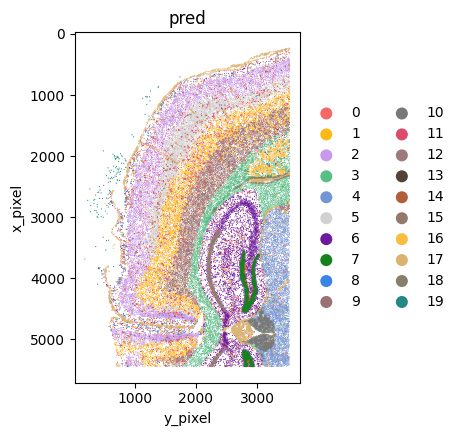

In [40]:
# adata=sc.read("results.h5ad")
from itertools import cycle

#Set colors used
plot_color=["#F56867","#FEB915","#C798EE","#59BE86","#7495D3","#D1D1D1","#6D1A9C","#15821E","#3A84E6","#997273","#787878","#DB4C6C","#9E7A7A","#554236","#AF5F3C","#93796C","#F9BD3F","#DAB370","#877F6C","#268785"]
#Plot spatial domains
domains="pred"
# num_celltype=len(adata.obs[domains].unique())
# adata.uns[domains+"_colors"]=list(plot_color[:num_celltype])
# ensure it's categorical
adata.obs[domains] = adata.obs[domains].astype("category")

# get the exact number of categories
num_celltype = len(adata.obs[domains].cat.categories)

# assign colors respecting category order
adata.uns[domains + "_colors"] = [c for _, c in zip(range(num_celltype), cycle(plot_color))]

ax = sc.pl.scatter(
    adata,
    alpha=1,
    x="y_pixel",
    y="x_pixel",
    color=domains,
    title=domains,
    show=False,
    size=100000 / adata.shape[0]
)
ax.set_aspect('equal', 'box')
ax.invert_yaxis()
plt.show()


# ax=sc.pl.scatter(adata,alpha=1,x="y_pixel",y="x_pixel",color=domains,title=domains,color_map=plot_color,show=False,size=100000/adata.shape[0])
# ax.set_aspect('equal', 'box')
# ax.axes.invert_yaxis()
# # plt.savefig("pred.png", dpi=600)
# plt.show()


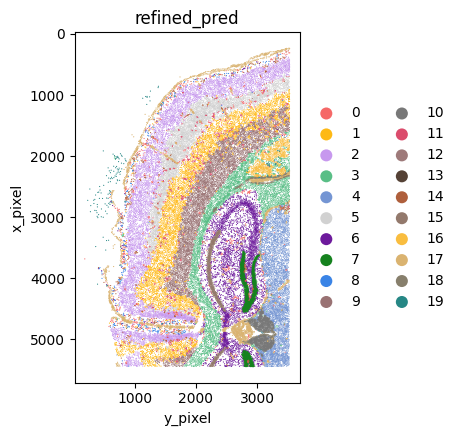

In [41]:
# adata=sc.read("results.h5ad")
from itertools import cycle

#Set colors used
plot_color=["#F56867","#FEB915","#C798EE","#59BE86","#7495D3","#D1D1D1","#6D1A9C","#15821E","#3A84E6","#997273","#787878","#DB4C6C","#9E7A7A","#554236","#AF5F3C","#93796C","#F9BD3F","#DAB370","#877F6C","#268785"]
#Plot spatial domains
domains="refined_pred"
# num_celltype=len(adata.obs[domains].unique())
# adata.uns[domains+"_colors"]=list(plot_color[:num_celltype])
# ensure it's categorical
adata.obs[domains] = adata.obs[domains].astype("category")

# get the exact number of categories
num_celltype = len(adata.obs[domains].cat.categories)

# assign colors respecting category order
adata.uns[domains + "_colors"] = [c for _, c in zip(range(num_celltype), cycle(plot_color))]

ax = sc.pl.scatter(
    adata,
    alpha=1,
    x="y_pixel",
    y="x_pixel",
    color=domains,
    title=domains,
    show=False,
    size=100000 / adata.shape[0]
)
ax.set_aspect('equal', 'box')
ax.invert_yaxis()
plt.show()


# ax=sc.pl.scatter(adata,alpha=1,x="y_pixel",y="x_pixel",color=domains,title=domains,color_map=plot_color,show=False,size=100000/adata.shape[0])
# ax.set_aspect('equal', 'box')
# ax.axes.invert_yaxis()
# # plt.savefig("pred.png", dpi=600)
# plt.show()








# #Plot refined spatial domains
# domains="refined_pred"
# num_celltype=len(adata.obs[domains].unique())
# adata.uns[domains+"_colors"]=list(plot_color[:num_celltype])
# ax=sc.pl.scatter(adata,alpha=1,x="y_pixel",y="x_pixel",color=domains,title=domains,color_map=plot_color,show=False,size=100000/adata.shape[0])
# ax.set_aspect('equal', 'box')
# ax.axes.invert_yaxis()
# # plt.savefig("refined_pred.png", dpi=600)
# plt.show()


**Spatial Domains**![](./sample_results/pred.png) **Refined Spatial Domains**![](./sample_results/refined_pred.png)

### 6. Identify SVGs

In [12]:
#Read in raw data
raw=sc.read("../tutorial/data/151673/sample_data.h5ad")
raw.var_names_make_unique()
raw.obs["pred"]=adata.obs["pred"].astype('category')
raw.obs["x_array"]=raw.obs["x2"]
raw.obs["y_array"]=raw.obs["x3"]
raw.obs["x_pixel"]=raw.obs["x4"]
raw.obs["y_pixel"]=raw.obs["x5"]
#Convert sparse matrix to non-sparse
raw.X=(raw.X.A if issparse(raw.X) else raw.X)
raw.raw=raw
sc.pp.log1p(raw)

Variable names are not unique. To make them unique, call `.var_names_make_unique`.


- target: Target domain to identify SVGs.
- min_in_group_fraction: Minium in-group expression fraction.
- min_in_out_group_ratio: Miniumn (in-group expression fraction) / (out-group expression fraction).
- min_fold_change: Miniumn (in-group expression) / (out-group expression).
- r: Radius to detect a spot's neighboring spots.

In [15]:
#Use domain 0 as an example
target=0
#Set filtering criterials
min_in_group_fraction=0.8
min_in_out_group_ratio=1
min_fold_change=1.5
#Search radius such that each spot in the target domain has approximately 10 neighbors on average
adj_2d=spg.calculate_adj_matrix(x=x_array, y=y_array, histology=False)
start, end= np.quantile(adj_2d[adj_2d!=0],q=0.001), np.quantile(adj_2d[adj_2d!=0],q=0.1)
r=spg.search_radius(target_cluster=target, cell_id=adata.obs.index.tolist(), x=x_array, y=y_array, pred=adata.obs["pred"].tolist(), start=start, end=end, num_min=10, num_max=14,  max_run=100)
#Detect neighboring domains
nbr_domians=spg.find_neighbor_clusters(target_cluster=target,
                                   cell_id=raw.obs.index.tolist(), 
                                   x=raw.obs["x_array"].tolist(), 
                                   y=raw.obs["y_array"].tolist(), 
                                   pred=raw.obs["pred"].tolist(),
                                   radius=r,
                                   ratio=1/2)

nbr_domians=nbr_domians[0:3]
de_genes_info=spg.rank_genes_groups(input_adata=raw,
                                target_cluster=target,
                                nbr_list=nbr_domians, 
                                label_col="pred", 
                                adj_nbr=True, 
                                log=True)
#Filter genes
de_genes_info=de_genes_info[(de_genes_info["pvals_adj"]<0.05)]
filtered_info=de_genes_info
filtered_info=filtered_info[(filtered_info["pvals_adj"]<0.05) &
                            (filtered_info["in_out_group_ratio"]>min_in_out_group_ratio) &
                            (filtered_info["in_group_fraction"]>min_in_group_fraction) &
                            (filtered_info["fold_change"]>min_fold_change)]
filtered_info=filtered_info.sort_values(by="in_group_fraction", ascending=False)
filtered_info["target_dmain"]=target
filtered_info["neighbors"]=str(nbr_domians)
print("SVGs for domain ", str(target),":", filtered_info["genes"].tolist())

Calculateing adj matrix using xy only...
Calculateing adj matrix using xy only...
Calculateing adj matrix using xy only...
Run 1: radius [1.4142135381698608, 16.970561981201172], num_nbr [1.0, 321.149863760218]
Calculateing adj matrix using xy only...
Run 2: radius [1.4142135381698608, 9.192387759685516], num_nbr [1.0, 117.8283378746594]
Calculateing adj matrix using xy only...
Run 3: radius [1.4142135381698608, 5.303300648927689], num_nbr [1.0, 41.85013623978202]
Calculateing adj matrix using xy only...
Run 4: radius [1.4142135381698608, 3.3587570935487747], num_nbr [1.0, 20.04632152588556]
Calculateing adj matrix using xy only...
Run 5: radius [2.386485315859318, 3.3587570935487747], num_nbr [8.7574931880109, 20.04632152588556]
Calculateing adj matrix using xy only...
recommended radius =  2.8726212047040462 num_nbr=12.524523160762943
radius= 2.8726212047040462 average number of neighbors for each spot is 12.524523160762943
 Cluster 0 has neighbors:
Dmain  3 :  863
Dmain  2 :  517
SV

In [82]:
filtered_info

,genes,in_group_fraction,out_group_fraction,in_out_group_ratio,in_group_mean_exp,out_group_mean_exp,fold_change,pvals_adj,target_dmain,neighbors
0,CAMK2N1,1.000000,0.944964,1.058242,2.333675,1.578288,2.128434,1.656040e-11,0,"[3, 2]"
2,ENC1,0.998638,0.941848,1.060295,2.457791,1.696083,2.141931,1.552131e-03,0,"[3, 2]"
4,GPM6A,0.997275,0.922118,1.081505,2.224006,1.561187,1.940255,8.602227e-03,0,"[3, 2]"
6,ARPP19,0.982289,0.853583,1.150784,1.889256,1.272106,1.853637,4.823349e-02,0,"[3, 2]"
1,HPCAL1,0.851499,0.465213,1.830342,1.141321,0.406338,2.085448,9.706465e-05,0,"[3, 2]"


In [103]:
#Plot refinedspatial domains
color_self = clr.LinearSegmentedColormap.from_list('pink_green', ['#3AB370',"#EAE7CC","#FD1593"], N=256)
for g in filtered_info["genes"].tolist():
    raw.obs["exp"]=raw.X[:,raw.var.index==g]
    ax=sc.pl.scatter(raw,alpha=1,x="y_pixel",y="x_pixel",color="exp",title=g,color_map=color_self,show=False,size=100000/raw.shape[0])
    ax.set_aspect('equal', 'box')
    ax.axes.invert_yaxis()
    plt.savefig("./sample_results/"+g+".png", dpi=600)
    plt.close()


**CAMK2N1**![](./sample_results/CAMK2N1.png) **ENC1**![](./sample_results/ENC1.png) **GPM6A**![](./sample_results/GPM6A.png) **ARPP19**![](./sample_results/ARPP19.png) **HPCAL1**![](./sample_results/HPCAL1.png)

### 7. Identify Meta Gene

In [132]:
#Use domain 2 as an example
target=2
meta_name, meta_exp=spg.find_meta_gene(input_adata=raw,
                    pred=raw.obs["pred"].tolist(),
                    target_domain=target,
                    start_gene="GFAP",
                    mean_diff=0,
                    early_stop=True,
                    max_iter=3,
                    use_raw=False)

raw.obs["meta"]=meta_exp

Trying to set attribute `.obs` of view, copying.
Trying to set attribute `.obs` of view, copying.


Add gene:  MGP
Minus gene:  FTH1
Absolute mean change: 0.8913243
Number of non-target spots reduced to: 1888
Meta gene is:  GFAP+MGP-FTH1


Trying to set attribute `.obs` of view, copying.


Add gene:  MYL9
Minus gene:  MBP
Absolute mean change: 2.175557
Number of non-target spots reduced to: 563
Meta gene is:  GFAP+MGP-FTH1+MYL9-MBP
Add gene:  KRT8
Minus gene:  MT-ATP6
Absolute mean change: 2.8935516
Number of non-target spots reduced to: 111
Meta gene is:  GFAP+MGP-FTH1+MYL9-MBP+KRT8-MT-ATP6


In [133]:
#Plot meta gene
g="GFAP"
raw.obs["exp"]=raw.X[:,raw.var.index==g]
ax=sc.pl.scatter(raw,alpha=1,x="y_pixel",y="x_pixel",color="exp",title=g,color_map=color_self,show=False,size=100000/raw.shape[0])
ax.set_aspect('equal', 'box')
ax.axes.invert_yaxis()
plt.savefig("./sample_results/"+g+".png", dpi=600)
plt.close()

raw.obs["exp"]=raw.obs["meta"]
ax=sc.pl.scatter(raw,alpha=1,x="y_pixel",y="x_pixel",color="exp",title=meta_name,color_map=color_self,show=False,size=100000/raw.shape[0])
ax.set_aspect('equal', 'box')
ax.axes.invert_yaxis()
plt.savefig("./sample_results/meta_gene.png", dpi=600)
plt.close()


**start**![](./sample_results/GFAP.png) **meta gene**![](./sample_results/meta_gene.png)

### 8. Multiple tissue sections analysis
In this section, we show an example on how to analysis multiple adjacent tissue sections using SpaGCN.

**Mouse brain anterior**![](./sample_results/MA1_lowres.png) **Mouse brain posterior**![](./sample_results/MP1_lowres.png)

#### 8.1 Read in data

In [30]:
adata1=sc.read("./data/Mouse_brain/MA1.h5ad")
adata2=sc.read("./data/Mouse_brain/MP1.h5ad")
img1=cv2.imread("./data/Mouse_brain/MA1_histology.tif")
img2=cv2.imread("./data/Mouse_brain/MP1_histology.tif")

Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.


#### 8.2 Extract color intensity

In [31]:
b=49
s=1
x_pixel1=adata1.obs["x4"].tolist()
y_pixel1=adata1.obs["x5"].tolist()
adata1.obs["color"]=spg.extract_color(x_pixel=x_pixel1, y_pixel=y_pixel1, image=img1, beta=b)
z_scale=np.max([np.std(x_pixel1), np.std(y_pixel1)])*s
adata1.obs["z"]=(adata1.obs["color"]-np.mean(adata1.obs["color"]))/np.std(adata1.obs["color"])*z_scale

x_pixel2=adata2.obs["x4"].tolist()
y_pixel2=adata2.obs["x5"].tolist()
adata2.obs["color"]=spg.extract_color(x_pixel=x_pixel2, y_pixel=y_pixel2, image=img2, beta=b)
z_scale=np.max([np.std(x_pixel2), np.std(y_pixel2)])*s
adata2.obs["z"]=(adata2.obs["color"]-np.mean(adata2.obs["color"]))/np.std(adata2.obs["color"])*z_scale
del img1, img2

#### 8.3 Modify coordinates to combine 2 sections

In [32]:
from anndata import AnnData
adata1.obs["x_pixel"]=x_pixel1
adata1.obs["y_pixel"]=y_pixel1
adata2.obs["x_pixel"]=x_pixel2-np.min(x_pixel2)+np.min(x_pixel1)
adata2.obs["y_pixel"]=y_pixel2-np.min(y_pixel2)+np.max(y_pixel1)
adata1.var_names_make_unique()
adata2.var_names_make_unique()
adata_all=AnnData.concatenate(adata1, adata2,join='inner',batch_key="dataset_batch",batch_categories=["0","1"])

#### 8.4 Integrate gene expression and histology into a Graph

In [34]:
X=np.array([adata_all.obs["x_pixel"], adata_all.obs["y_pixel"], adata_all.obs["z"]]).T.astype(np.float32)
adj=spg.pairwise_distance(X)

#### 8.5 Spatial domain detection using SpaGCN

In [37]:
sc.pp.normalize_per_cell(adata_all, min_counts=0)
sc.pp.log1p(adata_all)
p=0.5 
#Find the l value given p
l=spg.search_l(p, adj, start=0.01, end=1000, tol=0.01, max_run=100)

Run 1: l [0.01, 1000], p [0.0, 144.17116893743565]
Run 2: l [0.01, 500.005], p [0.0, 24.78992462158203]
Run 3: l [0.01, 250.0075], p [0.0, 3.649960994720459]
Run 4: l [125.00874999999999, 250.0075], p [0.4487175941467285, 3.649960994720459]
Run 5: l [125.00874999999999, 187.508125], p [0.4487175941467285, 1.5741894245147705]
Run 6: l [125.00874999999999, 156.2584375], p [0.4487175941467285, 0.9070142507553101]
Run 7: l [125.00874999999999, 140.63359375], p [0.4487175941467285, 0.6537595987319946]
Run 8: l [125.00874999999999, 132.821171875], p [0.4487175941467285, 0.5454769134521484]
recommended l =  128.91496093749998


In [43]:
res=1.0
seed=100
random.seed(seed)
torch.manual_seed(seed)
np.random.seed(seed)
clf=spg.SpaGCN()
clf.set_l(l)
clf.train(adata_all,adj,init_spa=True,init="louvain",res=res, tol=5e-3, lr=0.05, max_epochs=200)
y_pred, prob=clf.predict()
adata_all.obs["pred"]= y_pred
adata_all.obs["pred"]=adata_all.obs["pred"].astype('category')

Initializing cluster centers with louvain, resolution =  1.0
Epoch  0
Epoch  10
Epoch  20
Epoch  30
delta_label  0.004794180856339891 < tol  0.005
Reach tolerance threshold. Stopping training.
Total epoch: 37


In [44]:
colors_use=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#bcbd22', '#17becf', '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#bec1d4', '#bb7784', '#0000ff', '#111010', '#FFFF00',   '#1f77b4', '#800080', '#959595', 
 '#7d87b9', '#bec1d4', '#d6bcc0', '#bb7784', '#8e063b', '#4a6fe3', '#8595e1', '#b5bbe3', '#e6afb9', '#e07b91', '#d33f6a', '#11c638', '#8dd593', '#c6dec7', '#ead3c6', '#f0b98d', '#ef9708', '#0fcfc0', '#9cded6', '#d5eae7', '#f3e1eb', '#f6c4e1', '#f79cd4']
num_celltype=len(adata_all.obs["pred"].unique())
adata_all.uns["pred_colors"]=list(colors_use[:num_celltype])
ax=sc.pl.scatter(adata_all,alpha=1,x="y_pixel",y="x_pixel",color="pred",show=False,size=150000/adata_all.shape[0])
ax.set_aspect('equal', 'box')
ax.axes.invert_yaxis()
plt.savefig("./sample_results/mouse_barin_muti_sections_domains.png", dpi=600)
plt.close()

**SpaGCN mouse brain combines**![](./sample_results/mouse_barin_muti_sections_domains.png)